# Segunda entrega taller de proyecto
Estefanía Pizarro Arias

# **1.Librerias y vinculación a google drive**

In [198]:
# librerias
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [199]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2.Cargar bases de información**

*   Huertos

In [200]:
# Informacion de los predios de los Huertos
# Se rescata solo información tabular, descartando datos espaciales (coordenadas del fid)
huertos = pd.read_excel("/content/drive/MyDrive/Diplomado_DS/Segunda_entrega/Data_set/df_huertos.xlsx")
huertos['fid'] = huertos['fid'].astype('object')
huertos

,fid,client,orchard,area_fid
0,3,Alex_Sedano,Canadilla,66047.988
1,8,Alex_Sedano,Canadilla,226199.186
2,10,Alex_Sedano,Canadilla,40057.697
3,11,Alex_Sedano,Canadilla,34444.281
4,12,Alex_Sedano,Canadilla,17266.185
...,...,...,...,...
64,97,Rucaray,Santa_Julia,43744.231
65,124,Sebastian_Warnier,Santa_Victoria,9811.591
66,125,Sebastian_Warnier,Santa_Victoria,20662.306
67,126,Sebastian_Warnier,Santa_Victoria,9942.136


* Indices satelitales

In [201]:
# Información serie temporal indices satelitales
# Ver codigo "Serie_diaria_VI" para derivación de variables
indices = pd.read_excel("/content/drive/MyDrive/Diplomado_DS/Segunda_entrega/Data_set/df_indices.xlsx")
indices = indices[['fid','date', 'timeline','ndvi_f','savi_f', 'slavi_f', 'season']]
indices['fid'] = indices['fid'].astype('object')
indices

,fid,date,timeline,ndvi_f,savi_f,slavi_f,season
0,3,2021-09-05,0,0.218975,0.120901,0.598996,21-22
1,3,2021-09-06,1,0.224645,0.124644,0.609034,21-22
2,3,2021-09-07,2,0.230314,0.128388,0.619072,21-22
3,3,2021-09-08,3,0.235984,0.132131,0.629111,21-22
4,3,2021-09-09,4,0.241654,0.135875,0.639149,21-22
...,...,...,...,...,...,...,...
47347,127,2024-04-23,221,0.482598,0.133925,1.071612,23-24
47348,127,2024-04-24,222,0.479029,0.127417,1.054443,23-24
47349,127,2024-04-25,223,0.475460,0.120908,1.037275,23-24
47350,127,2024-04-26,224,0.471892,0.114399,1.020106,23-24


* Derivadas topogaficas

In [202]:
# Información de derivadas topograficas del DEM de los huertos
topografia  = pd.read_csv("/content/drive/MyDrive/Diplomado_DS/Segunda_entrega/Data_set/df_topo.csv")
topografia['fid'] = topografia['fid'].astype('object')
topografia

,fid,elevation,slope,hillshade
0,3,321.489329,2.111452,180.046017
1,8,322.933094,1.974027,181.385008
2,10,322.138615,2.922333,181.088217
3,11,314.932313,2.312445,182.048740
4,12,314.421415,1.778518,181.838147
...,...,...,...,...
64,97,509.638145,1.338157,182.111413
65,124,137.330501,1.233475,180.869249
66,125,137.973464,0.881964,181.494272
67,126,137.282324,1.471350,180.642538


* Propiedades fisicas de suelo

In [203]:
# Información de propiedades fisicas de suelo
suelos  = pd.read_excel("/content/drive/MyDrive/Diplomado_DS/Segunda_entrega/Data_set/df_suelos.xlsx")
suelos['fid'] = suelos['fid'].astype('object')
suelos

,fid,clay_0_5,clay_100_200,clay_15_30,clay_30_60,clay_5_15,clay_60_100,sand_0_5,sand_100_200,sand_15_30,sand_30_60,sand_5_15,sand_60_100,silt_0_5,silt_100_200,silt_15_30,silt_30_60,silt_5_15,silt_60_100
0,3,21.100000,23.100000,23.700000,24.000000,22.200000,23.300,47.500000,48.200000,46.000,47.200000,46.500000,47.700,31.400,28.700000,30.400000,28.700000,31.400000,29.000
1,8,20.960000,22.340000,23.000000,22.840000,21.800000,22.200,47.320000,48.800000,46.080,47.760000,46.360000,48.420,31.740,28.860000,30.920000,29.400000,31.820000,29.360
2,10,20.900000,23.000000,23.150000,23.725000,21.800000,23.175,47.750000,48.325000,46.450,47.400000,46.850000,47.825,31.375,28.675000,30.450000,28.850000,31.375000,29.025
3,11,20.775000,23.450000,22.200000,23.150000,21.475000,23.000,48.125000,48.075000,47.425,48.000000,47.600000,47.900,31.100,28.500000,30.375000,28.850000,30.925000,29.075
4,12,20.650000,23.425000,22.050000,23.075000,21.375000,22.900,48.175000,48.200000,47.600,48.125000,47.650000,48.100,31.175,28.400000,30.325000,28.800000,30.950000,28.975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,97,18.300000,20.100000,19.100000,19.500000,18.800000,18.700,40.200000,41.100000,40.900,40.800000,40.700000,41.300,41.500,38.700000,40.000000,39.800000,40.600000,40.000
65,124,22.400000,19.700000,24.600000,22.600000,24.400000,21.200,49.200000,52.500000,47.300,49.500000,47.000000,51.800,28.400,27.800000,28.100000,27.900000,28.600000,27.000
66,125,22.333333,19.833333,24.566667,22.666667,24.333333,21.300,49.066667,52.733333,47.400,49.566667,47.066667,52.000,28.600,27.433333,28.066667,27.766667,28.566667,26.700
67,126,22.250000,19.750000,24.650000,22.650000,24.250000,21.200,49.350000,52.550000,47.350,49.550000,47.200000,51.850,28.350,27.700000,28.000000,27.800000,28.550000,26.900


* Datos meteorológicos

In [204]:
# Información meteorológica (informacion a escala horaria)
meteo   = pd.read_csv("/content/drive/MyDrive/Diplomado_DS/Segunda_entrega/Data_set/clima_analytics.csv")
meteo['stationId'] = meteo['stationId'].astype(str)
meteo

<ipython-input-204-cc9f4250879e>:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  meteo   = pd.read_csv("/content/drive/MyDrive/Diplomado_DS/Segunda_entrega/Data_set/clima_analytics.csv")


,client,dataSource,orchard,datetime,stationId,tempMean,tempMax,tempMin,precipitation,relativeHumidityMean,...,relativeHumidityMin,windSpeed,radiation,dewPointMean,dewPointMin,dewPointMax,eto,pfValue,hfValue,__v
0,Alex_Sedano,Vilab,Canadilla,2024-07-31T21:00:00Z,5918,11.10,11.10,11.10,0.0,81.00,...,81.00,11.1,19.0,NaN,NaN,NaN,NaN,0.0,0,NaN
1,Alex_Sedano,Vilab,Canadilla,2024-07-31T20:00:00Z,5918,11.50,11.50,11.50,0.0,80.00,...,80.00,11.5,54.0,NaN,NaN,NaN,NaN,0.0,0,NaN
2,Alex_Sedano,Vilab,Canadilla,2024-07-31T19:00:00Z,5918,12.00,12.00,12.00,0.0,77.00,...,77.00,12.0,60.0,NaN,NaN,NaN,NaN,0.0,0,NaN
3,Alex_Sedano,Vilab,Canadilla,2024-07-31T18:00:00Z,5918,11.70,11.70,11.70,0.0,76.00,...,76.00,11.7,77.0,NaN,NaN,NaN,NaN,0.0,0,NaN
4,Alex_Sedano,Vilab,Canadilla,2024-07-31T17:00:00Z,5918,10.70,10.70,10.70,0.0,84.00,...,84.00,10.7,139.0,NaN,NaN,NaN,NaN,0.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494881,Sebastian_Warnier,AGViewer,Santa_Victoria,2021-01-01T04:00:00Z,2023,14.57,14.72,14.41,0.0,68.41,...,67.33,NaN,0.0,8.8,8.6,NaN,NaN,0.0,0,0.0
494882,Sebastian_Warnier,AGViewer,Santa_Victoria,2021-01-01T03:45:00Z,2023,15.08,15.15,14.96,0.0,64.23,...,62.15,NaN,0.0,8.3,7.9,NaN,NaN,0.0,0,0.0
494883,Sebastian_Warnier,AGViewer,Santa_Victoria,2021-01-01T03:30:00Z,2023,15.03,15.20,14.88,0.0,62.65,...,59.42,NaN,0.0,7.9,7.3,NaN,NaN,0.0,0,0.0
494884,Sebastian_Warnier,AGViewer,Santa_Victoria,2021-01-01T03:15:00Z,2023,15.59,15.74,15.37,0.0,59.80,...,59.10,NaN,0.0,7.7,7.7,NaN,NaN,0.0,0,0.0


In [205]:
print(meteo.isnull().sum())

client                       0
dataSource                   0
orchard                      0
datetime                    29
stationId                    0
tempMean                    32
tempMax                     32
tempMin                     32
precipitation               34
relativeHumidityMean        32
relativeHumidityMax         32
relativeHumidityMin         32
windSpeed               422615
radiation                   32
dewPointMean            278388
dewPointMin             278388
dewPointMax             494886
eto                     478561
pfValue                      0
hfValue                      0
__v                      55741
dtype: int64


In [206]:
# Rescatar stationId del huerto de cada cliente
id_station = meteo[['client','orchard','stationId']].drop_duplicates()
print(id_station)

                   client         orchard stationId
0             Alex_Sedano       Canadilla      5918
119563     Almahue_Export       Los_Palos      5920
156827       Garces_Fruit         Almahue  0020361D
198500       Garces_Fruit    Santa_Monica    203580
257468            Rucaray     Santa_Julia      5967
378997  Sebastian_Warnier  Santa_Victoria      2023


# **3.Preprocesamiento bases**

*Preprocesamiento de datos de predios*

1. Ajustar área a hectáreas y unir stationId a cada huerto

In [207]:
# ajustar area a hectareas
huertos['area'] = huertos['area_fid']/10000
# unir id de estacion meteorologica
df_huertos =  pd.merge(huertos, id_station, how='left', on= ['client','orchard'])
df_huertos = df_huertos[['fid','client', 'orchard','stationId','area']]
df_huertos

,fid,client,orchard,stationId,area
0,3,Alex_Sedano,Canadilla,5918,6.604799
1,8,Alex_Sedano,Canadilla,5918,22.619919
2,10,Alex_Sedano,Canadilla,5918,4.005770
3,11,Alex_Sedano,Canadilla,5918,3.444428
4,12,Alex_Sedano,Canadilla,5918,1.726619
...,...,...,...,...,...
64,97,Rucaray,Santa_Julia,5967,4.374423
65,124,Sebastian_Warnier,Santa_Victoria,2023,0.981159
66,125,Sebastian_Warnier,Santa_Victoria,2023,2.066231
67,126,Sebastian_Warnier,Santa_Victoria,2023,0.994214


In [208]:
# Variables de id de estacion para cada fid (llave necesaria para unir base satelital y meteorologica)
fid_idstation = df_huertos[['fid', 'stationId']]

*Preprocesamiento de datos indices satelitales*

1. Unir 'stationId' del fid con base satelital

In [209]:
df_indices = fid_idstation.merge(indices, on = 'fid')
df_indices

,fid,stationId,date,timeline,ndvi_f,savi_f,slavi_f,season
0,3,5918,2021-09-05,0,0.218975,0.120901,0.598996,21-22
1,3,5918,2021-09-06,1,0.224645,0.124644,0.609034,21-22
2,3,5918,2021-09-07,2,0.230314,0.128388,0.619072,21-22
3,3,5918,2021-09-08,3,0.235984,0.132131,0.629111,21-22
4,3,5918,2021-09-09,4,0.241654,0.135875,0.639149,21-22
...,...,...,...,...,...,...,...,...
47347,127,2023,2024-04-23,221,0.482598,0.133925,1.071612,23-24
47348,127,2023,2024-04-24,222,0.479029,0.127417,1.054443,23-24
47349,127,2023,2024-04-25,223,0.475460,0.120908,1.037275,23-24
47350,127,2023,2024-04-26,224,0.471892,0.114399,1.020106,23-24


*Preprocesamiento de datos topografía*

1. Base sin preprocesamiento de datos

In [210]:
df_topografia = topografia
df_topografia

,fid,elevation,slope,hillshade
0,3,321.489329,2.111452,180.046017
1,8,322.933094,1.974027,181.385008
2,10,322.138615,2.922333,181.088217
3,11,314.932313,2.312445,182.048740
4,12,314.421415,1.778518,181.838147
...,...,...,...,...
64,97,509.638145,1.338157,182.111413
65,124,137.330501,1.233475,180.869249
66,125,137.973464,0.881964,181.494272
67,126,137.282324,1.471350,180.642538


*Preprocesamiento de datos propiedades físicas*

1. Estimación de promedio de Arcilla, Arena y Limo para el perfil completo del suelo

In [211]:
# Derivación de los datos de propiedades de suelo
# Calcular los contenidos de arcilla, arena y limo para el perfil completo de cada huerto
suelos['CLAY'] = suelos.filter(like='clay').mean(axis=1, skipna=True)
suelos['SAND'] = suelos.filter(like='sand').mean(axis=1, skipna=True)
suelos['SILT'] = suelos.filter(like='silt').mean(axis=1, skipna=True)
# Reducción de datos, selección del promedio para el perfil de suelo
df_suelos = suelos[['fid','CLAY', 'SAND','SILT']]
df_suelos

,fid,CLAY,SAND,SILT
0,3,22.900000,47.183333,29.933333
1,8,22.190000,47.456667,30.350000
2,10,22.625000,47.433333,29.958333
3,11,22.341667,47.854167,29.804167
4,12,22.245833,47.975000,29.770833
...,...,...,...,...
64,97,19.083333,40.833333,40.100000
65,124,22.483333,49.550000,27.966667
66,125,22.505556,49.638889,27.855556
67,126,22.458333,49.641667,27.883333


*Preprocesamiento de datos meteorológicos*



1. Filtrar fechas de temporadas de riego

In [212]:
# Filtro temporadas  (3 temporadas de estudio)
# Obtener solo la fecha de la columna (datetime contiene la hora)
meteo['datetime'] = pd.to_datetime(meteo['datetime'])
meteo['date'] = meteo['datetime'].dt.date
meteo['date'] = pd.to_datetime(meteo['date'])

In [213]:
# Temporada 1
fi_t1 = pd.to_datetime('2021-09-01')
ff_t1 = pd.to_datetime('2022-04-30')
s1 = meteo[(meteo['date'] >= fi_t1) & (meteo['date'] <= ff_t1)]
s1['season'] = '21-22'

# Temporada 2
fi_t2 = pd.to_datetime('2022-09-01')
ff_t2 = pd.to_datetime('2023-04-30')
s2 = meteo[(meteo['date'] >= fi_t2) & (meteo['date'] <= ff_t2)]
s2['season'] = '22-23'

# Temporada 3
fi_t3 = pd.to_datetime('2023-09-01')
ff_t3 = pd.to_datetime('2024-04-30')
s3 = meteo[(meteo['date'] >= fi_t3) & (meteo['date'] <= ff_t3)]
s3['season'] = '23-24'

# Unir los DataFrames de temporadas filtradas
df_meteo = pd.concat([s1, s2, s3])
df_meteo.head(6)

<ipython-input-213-287a3d2ced0f>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s1['season'] = '21-22'
<ipython-input-213-287a3d2ced0f>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s2['season'] = '22-23'
<ipython-input-213-287a3d2ced0f>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

,client,dataSource,orchard,datetime,stationId,tempMean,tempMax,tempMin,precipitation,relativeHumidityMean,...,radiation,dewPointMean,dewPointMin,dewPointMax,eto,pfValue,hfValue,__v,date,season
19991,Alex_Sedano,Vilab,Canadilla,2022-04-30 23:00:00+00:00,5918,13.0,13.0,13.0,0.0,71.2,...,0.0,NaN,NaN,NaN,NaN,0.0,0,0.0,2022-04-30,21-22
19992,Alex_Sedano,Vilab,Canadilla,2022-04-30 22:00:00+00:00,5918,14.3,14.3,14.3,0.0,66.2,...,0.0,NaN,NaN,NaN,NaN,0.0,0,0.0,2022-04-30,21-22
19993,Alex_Sedano,Vilab,Canadilla,2022-04-30 21:00:00+00:00,5918,16.3,16.3,16.3,0.0,59.2,...,19.9,NaN,NaN,NaN,NaN,0.0,0,0.0,2022-04-30,21-22
19994,Alex_Sedano,Vilab,Canadilla,2022-04-30 20:00:00+00:00,5918,17.9,17.9,17.9,0.0,55.0,...,298.9,NaN,NaN,NaN,NaN,0.0,0,0.0,2022-04-30,21-22
19995,Alex_Sedano,Vilab,Canadilla,2022-04-30 19:00:00+00:00,5918,18.5,18.5,18.5,0.0,55.5,...,429.4,NaN,NaN,NaN,NaN,0.0,0,0.0,2022-04-30,21-22
19996,Alex_Sedano,Vilab,Canadilla,2022-04-30 18:00:00+00:00,5918,18.2,18.2,18.2,0.0,55.0,...,517.0,NaN,NaN,NaN,NaN,0.0,0,0.0,2022-04-30,21-22


2. Obtener variables derivadas de interés a escala diaria

In [214]:
# Obtener Temperatura minima, maxima y humedad relativa por dia (eliminar escala horaria)
df_meteo = df_meteo.groupby(['client','orchard', 'stationId', 'date','season']).agg(
    Tmin =('tempMin', 'min'), # Corresponde a valor minimo del dia
    Tmax =('tempMax', 'max'), # Corresponde a valor maximo del dia
    HR   =('relativeHumidityMean', 'mean') # Corresponde a la media del dia
).reset_index()

df_meteo['date']   = pd.to_datetime(df_meteo.date, format="%Y/%m/%d")
df_meteo

,client,orchard,stationId,date,season,Tmin,Tmax,HR
0,Alex_Sedano,Canadilla,5918,2021-09-01,21-22,7.20,17.80,76.916667
1,Alex_Sedano,Canadilla,5918,2021-09-02,21-22,5.10,19.90,75.333333
2,Alex_Sedano,Canadilla,5918,2021-09-03,21-22,9.10,20.20,88.500000
3,Alex_Sedano,Canadilla,5918,2021-09-04,21-22,8.60,19.20,76.112500
4,Alex_Sedano,Canadilla,5918,2021-09-05,21-22,5.10,20.00,72.175000
...,...,...,...,...,...,...,...,...
4211,Sebastian_Warnier,Santa_Victoria,2023,2024-04-26,23-24,4.07,21.89,75.578904
4212,Sebastian_Warnier,Santa_Victoria,2023,2024-04-27,23-24,6.64,19.72,59.240109
4213,Sebastian_Warnier,Santa_Victoria,2023,2024-04-28,23-24,6.71,18.74,61.146630
4214,Sebastian_Warnier,Santa_Victoria,2023,2024-04-29,23-24,1.10,18.52,75.036848


In [215]:
# Calculo variables derivadas
# Dias-grado
Tbase = 10
df_meteo['GDD'] = ((df_meteo['Tmax'] + df_meteo['Tmin'])/ 2) - Tbase
df_meteo['GDD_acum'] = df_meteo.groupby(['stationId', 'season'])['GDD'].cumsum()

# Deficit de presion de vapor
df_meteo['T'] = (df_meteo['Tmax'] + df_meteo['Tmin']) / 2
df_meteo['DPV'] = 0.6108 * np.exp((17.27 * df_meteo['T']) / (df_meteo['T'] + 237.3)) * (100 - df_meteo['HR']) / 100
df_meteo.head(5)

,client,orchard,stationId,date,season,Tmin,Tmax,HR,GDD,GDD_acum,T,DPV
0,Alex_Sedano,Canadilla,5918,2021-09-01,21-22,7.2,17.8,76.916667,2.50,2.50,12.50,0.334589
1,Alex_Sedano,Canadilla,5918,2021-09-02,21-22,5.1,19.9,75.333333,2.50,5.00,12.50,0.357539
2,Alex_Sedano,Canadilla,5918,2021-09-03,21-22,9.1,20.2,88.500000,4.65,9.65,14.65,0.191739
3,Alex_Sedano,Canadilla,5918,2021-09-04,21-22,8.6,19.2,76.112500,3.90,13.55,13.90,0.379396
4,Alex_Sedano,Canadilla,5918,2021-09-05,21-22,5.1,20.0,72.175000,2.55,16.10,12.55,0.404644


# **4.Descripción de los datos (tablas separadas)**

**1.  df_huertos**

In [216]:
# Informacion data frame
df_huertos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fid        69 non-null     object 
 1   client     69 non-null     object 
 2   orchard    69 non-null     object 
 3   stationId  69 non-null     object 
 4   area       69 non-null     float64
dtypes: float64(1), object(4)
memory usage: 2.8+ KB


In [217]:
# Estadistica descriptiva variables numericas
print(df_huertos.describe())

            area
count  69.000000
mean    5.210599
std     4.604304
min     0.723744
25%     2.066231
50%     3.863663
75%     6.372700
max    24.323390


In [218]:
# Obtener todos los únicos de la columna 'fid' (valores de los fid)
fid = df_huertos['fid'].unique()
fid

array([3, 8, 10, 11, 12, 13, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 77, 78, 79, 80, 81, 82, 83,
       84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 124, 125,
       126, 127], dtype=object)

In [219]:
# Obtener pares únicos de 'client' y 'orchard'
client_orchard = df_huertos[['client', 'orchard', 'stationId']].drop_duplicates()

print("cliente y orchard:")
print(client_orchard)

cliente y orchard:
               client         orchard stationId
0         Alex_Sedano       Canadilla      5918
7      Almahue_Export       Los_Palos      5920
9        Garces_Fruit         Almahue  0020361D
36       Garces_Fruit    Santa_Monica    203580
44            Rucaray     Santa_Julia      5967
65  Sebastian_Warnier  Santa_Victoria      2023


In [220]:
# Numero de cuerteles por huerto
df_huertos.groupby('orchard')['fid'].count()

,fid
orchard,
Almahue,27
Canadilla,7
Los_Palos,2
Santa_Julia,21
Santa_Monica,8
Santa_Victoria,4


In [221]:
# Datos nulos
print(df_huertos.isnull().sum())

fid          0
client       0
orchard      0
stationId    0
area         0
dtype: int64


**2. df_indices**

In [222]:
# Informacion data frame
df_indices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47352 entries, 0 to 47351
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   fid        47352 non-null  object        
 1   stationId  47352 non-null  object        
 2   date       47352 non-null  datetime64[ns]
 3   timeline   47352 non-null  int64         
 4   ndvi_f     47352 non-null  float64       
 5   savi_f     47352 non-null  float64       
 6   slavi_f    47352 non-null  float64       
 7   season     47352 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 2.9+ MB


In [223]:
# Estadistica descriptiva variables numericas
print(df_indices.describe())

                                date      timeline        ndvi_f  \
count                          47352  47352.000000  47352.000000   
mean   2022-12-25 22:48:33.938165760    113.975862      0.542079   
min              2021-09-05 00:00:00      0.000000      0.140954   
25%              2022-02-23 00:00:00     57.000000      0.476864   
50%              2022-12-21 00:00:00    114.000000      0.555506   
75%              2023-11-08 00:00:00    171.000000      0.620997   
max              2024-04-27 00:00:00    235.000000      0.814603   
std                              NaN     66.204739      0.109267   

             savi_f       slavi_f  
count  47352.000000  47352.000000  
mean       0.319449      1.238467  
min        0.060036      0.437499  
25%        0.275895      0.979410  
50%        0.324636      1.193578  
75%        0.369863      1.459164  
max        0.526064      2.870976  
std        0.073377      0.376091  


In [224]:
# Datos nulos
print(df_indices.isnull().sum())

fid          0
stationId    0
date         0
timeline     0
ndvi_f       0
savi_f       0
slavi_f      0
season       0
dtype: int64


**3. df_topografia**

In [225]:
# Informacion data frame
df_topografia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fid        69 non-null     object 
 1   elevation  69 non-null     float64
 2   slope      69 non-null     float64
 3   hillshade  69 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.3+ KB


In [226]:
# Estadistica descriptiva variables numericas
print(df_topografia.describe())

        elevation      slope   hillshade
count   69.000000  69.000000   69.000000
mean   322.270253   1.953788  181.270711
std    165.189820   0.963065    3.298614
min    136.522016   0.881964  164.040040
25%    155.635418   1.422665  180.077223
50%    314.932313   1.620155  181.144872
75%    513.238910   2.270017  182.198497
max    544.796599   6.103283  191.018987


In [227]:
# Datos nulos
print(df_topografia.isnull().sum())

fid          0
elevation    0
slope        0
hillshade    0
dtype: int64


**4. df_suelos**

In [228]:
# Informacion data frame
df_suelos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   fid     69 non-null     object 
 1   CLAY    69 non-null     float64
 2   SAND    69 non-null     float64
 3   SILT    69 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.3+ KB


In [229]:
# Estadistica descriptiva variables numericas
print(df_suelos.describe())

            CLAY       SAND       SILT
count  69.000000  69.000000  69.000000
mean   21.172476  45.029787  33.794211
std     1.600532   3.460736   5.001016
min    19.050000  40.833333  27.800000
25%    19.358333  41.400000  29.770833
50%    22.190000  46.858333  30.433333
75%    22.625000  47.883333  39.350000
max    23.266667  50.216667  40.100000


In [230]:
# Datos nulos
print(df_suelos.isnull().sum())

fid     0
CLAY    0
SAND    0
SILT    0
dtype: int64


**5. df_meteo**

In [231]:
# Informacion data frame
df_meteo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4216 entries, 0 to 4215
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   client     4216 non-null   object        
 1   orchard    4216 non-null   object        
 2   stationId  4216 non-null   object        
 3   date       4216 non-null   datetime64[ns]
 4   season     4216 non-null   object        
 5   Tmin       4216 non-null   float64       
 6   Tmax       4216 non-null   float64       
 7   HR         4216 non-null   float64       
 8   GDD        4216 non-null   float64       
 9   GDD_acum   4216 non-null   float64       
 10  T          4216 non-null   float64       
 11  DPV        4216 non-null   float64       
dtypes: datetime64[ns](1), float64(7), object(4)
memory usage: 395.4+ KB


In [232]:
# Estadistica descriptiva variables numericas
print(df_meteo.describe())

                                date         Tmin         Tmax           HR  \
count                           4216  4216.000000  4216.000000  4216.000000   
mean   2022-12-18 04:31:32.220113920     9.184615    26.647139    65.828213   
min              2021-09-01 00:00:00    -1.340000    10.600000    18.246667   
25%              2022-02-23 00:00:00     6.757500    22.427500    57.460208   
50%              2022-12-19 00:00:00     9.500000    27.980000    65.441082   
75%              2023-10-15 00:00:00    11.790000    31.100000    73.775339   
max              2024-04-30 00:00:00    24.100000    39.010000    99.038750   
std                              NaN     3.528295     5.610580    11.632547   

               GDD     GDD_acum            T          DPV  
count  4216.000000  4216.000000  4216.000000  4216.000000  
mean      7.915877   840.476862    17.915877     0.754508  
min      -2.600000    -0.450000     7.400000     0.011643  
25%       4.865000   216.216250    14.865000    

In [233]:
print(df_meteo.isnull().sum())

client       0
orchard      0
stationId    0
date         0
season       0
Tmin         0
Tmax         0
HR           0
GDD          0
GDD_acum     0
T            0
DPV          0
dtype: int64


# **5.Integración tablas y exploración**

**1. Vincular tablas**

1.1 Unión de tablas con datos a escala diaria

In [234]:
# Unión de datos que varían dia a dia
# df_meteo y df_indices (escala diaria)
df_combinado = pd.merge(df_indices, df_meteo, on=['stationId', 'date','season'], how='left')
# reordenar columnas de la tabla
df_vi_meteo  = df_combinado[['fid','client','orchard','stationId','date','season','timeline','ndvi_f','savi_f', 'slavi_f','T','Tmin','Tmax','HR','GDD','GDD_acum','DPV']]
df_vi_meteo

,fid,client,orchard,stationId,date,season,timeline,ndvi_f,savi_f,slavi_f,T,Tmin,Tmax,HR,GDD,GDD_acum,DPV
0,3,Alex_Sedano,Canadilla,5918,2021-09-05,21-22,0,0.218975,0.120901,0.598996,12.550,5.10,20.00,72.175000,2.550,16.100,0.404644
1,3,Alex_Sedano,Canadilla,5918,2021-09-06,21-22,1,0.224645,0.124644,0.609034,13.250,9.50,17.00,77.079167,3.250,19.350,0.348956
2,3,Alex_Sedano,Canadilla,5918,2021-09-07,21-22,2,0.230314,0.128388,0.619072,9.850,5.30,14.40,76.683333,-0.150,19.200,0.283455
3,3,Alex_Sedano,Canadilla,5918,2021-09-08,21-22,3,0.235984,0.132131,0.629111,9.550,2.20,16.90,77.183333,-0.450,18.750,0.271843
4,3,Alex_Sedano,Canadilla,5918,2021-09-09,21-22,4,0.241654,0.135875,0.639149,12.550,5.20,19.90,70.570833,2.550,21.300,0.427973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47347,127,Sebastian_Warnier,Santa_Victoria,2023,2024-04-23,23-24,221,0.482598,0.133925,1.071612,14.680,7.87,21.49,74.368696,4.680,921.620,0.428178
47348,127,Sebastian_Warnier,Santa_Victoria,2023,2024-04-24,23-24,222,0.479029,0.127417,1.054443,12.370,1.82,22.92,71.242717,2.370,923.990,0.413286
47349,127,Sebastian_Warnier,Santa_Victoria,2023,2024-04-25,23-24,223,0.475460,0.120908,1.037275,12.155,0.69,23.62,72.677160,2.155,926.145,0.387155
47350,127,Sebastian_Warnier,Santa_Victoria,2023,2024-04-26,23-24,224,0.471892,0.114399,1.020106,12.980,4.07,21.89,75.578904,2.980,929.125,0.365294


1.2 Unión de tablas con datos constantes

In [235]:
# Union de tablas con variables constantes
# df_huertos, df_topografia, df_suelos
df1 = pd.merge(df_huertos, df_topografia, how='left', on= ['fid'])
df_const = pd.merge(df1,  df_suelos, how='left', on= ['fid'])
df_const

,fid,client,orchard,stationId,area,elevation,slope,hillshade,CLAY,SAND,SILT
0,3,Alex_Sedano,Canadilla,5918,6.604799,321.489329,2.111452,180.046017,22.900000,47.183333,29.933333
1,8,Alex_Sedano,Canadilla,5918,22.619919,322.933094,1.974027,181.385008,22.190000,47.456667,30.350000
2,10,Alex_Sedano,Canadilla,5918,4.005770,322.138615,2.922333,181.088217,22.625000,47.433333,29.958333
3,11,Alex_Sedano,Canadilla,5918,3.444428,314.932313,2.312445,182.048740,22.341667,47.854167,29.804167
4,12,Alex_Sedano,Canadilla,5918,1.726619,314.421415,1.778518,181.838147,22.245833,47.975000,29.770833
...,...,...,...,...,...,...,...,...,...,...,...
64,97,Rucaray,Santa_Julia,5967,4.374423,509.638145,1.338157,182.111413,19.083333,40.833333,40.100000
65,124,Sebastian_Warnier,Santa_Victoria,2023,0.981159,137.330501,1.233475,180.869249,22.483333,49.550000,27.966667
66,125,Sebastian_Warnier,Santa_Victoria,2023,2.066231,137.973464,0.881964,181.494272,22.505556,49.638889,27.855556
67,126,Sebastian_Warnier,Santa_Victoria,2023,0.994214,137.282324,1.471350,180.642538,22.458333,49.641667,27.883333


1.3 Unión de todas las tablas

In [236]:
# Identificar las llaves comunes entre ambas tablas para unir sin duplicar columnas
common_keys = df_vi_meteo.columns.intersection(df_const.columns)
print("Llaves comunes:", common_keys)

Llaves comunes: Index(['fid', 'client', 'orchard', 'stationId'], dtype='object')


In [237]:
# Unir tablas por 'fid',  'stationId'
df_full = pd.merge(df_vi_meteo, df_const, how='left', on= ['fid', 'stationId'])
# Se opta por no unir por la llave comun que incluye client y orchad puesto que como viene con dato vacio por union previa, generá datos NA
# client y orchar duplican columnas por lo que se elimina el duplicado
df_full = df_full.drop(columns=['client_y', 'orchard_y'])
df_full

,fid,client_x,orchard_x,stationId,date,season,timeline,ndvi_f,savi_f,slavi_f,...,GDD,GDD_acum,DPV,area,elevation,slope,hillshade,CLAY,SAND,SILT
0,3,Alex_Sedano,Canadilla,5918,2021-09-05,21-22,0,0.218975,0.120901,0.598996,...,2.550,16.100,0.404644,6.604799,321.489329,2.111452,180.046017,22.900000,47.183333,29.933333
1,3,Alex_Sedano,Canadilla,5918,2021-09-06,21-22,1,0.224645,0.124644,0.609034,...,3.250,19.350,0.348956,6.604799,321.489329,2.111452,180.046017,22.900000,47.183333,29.933333
2,3,Alex_Sedano,Canadilla,5918,2021-09-07,21-22,2,0.230314,0.128388,0.619072,...,-0.150,19.200,0.283455,6.604799,321.489329,2.111452,180.046017,22.900000,47.183333,29.933333
3,3,Alex_Sedano,Canadilla,5918,2021-09-08,21-22,3,0.235984,0.132131,0.629111,...,-0.450,18.750,0.271843,6.604799,321.489329,2.111452,180.046017,22.900000,47.183333,29.933333
4,3,Alex_Sedano,Canadilla,5918,2021-09-09,21-22,4,0.241654,0.135875,0.639149,...,2.550,21.300,0.427973,6.604799,321.489329,2.111452,180.046017,22.900000,47.183333,29.933333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47347,127,Sebastian_Warnier,Santa_Victoria,2023,2024-04-23,23-24,221,0.482598,0.133925,1.071612,...,4.680,921.620,0.428178,2.004857,136.522016,1.588664,176.581232,22.433333,49.733333,27.800000
47348,127,Sebastian_Warnier,Santa_Victoria,2023,2024-04-24,23-24,222,0.479029,0.127417,1.054443,...,2.370,923.990,0.413286,2.004857,136.522016,1.588664,176.581232,22.433333,49.733333,27.800000
47349,127,Sebastian_Warnier,Santa_Victoria,2023,2024-04-25,23-24,223,0.475460,0.120908,1.037275,...,2.155,926.145,0.387155,2.004857,136.522016,1.588664,176.581232,22.433333,49.733333,27.800000
47350,127,Sebastian_Warnier,Santa_Victoria,2023,2024-04-26,23-24,224,0.471892,0.114399,1.020106,...,2.980,929.125,0.365294,2.004857,136.522016,1.588664,176.581232,22.433333,49.733333,27.800000


**2. Análisis exploratorio tablas por separado**

2.1 Tabla df_vi_meto

  *2.1.1 Resumen estadístico y cobertura*

In [238]:
# Información de variables df_vi_meteo
df_vi_meteo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47352 entries, 0 to 47351
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   fid        47352 non-null  object        
 1   client     46244 non-null  object        
 2   orchard    46244 non-null  object        
 3   stationId  47352 non-null  object        
 4   date       47352 non-null  datetime64[ns]
 5   season     47352 non-null  object        
 6   timeline   47352 non-null  int64         
 7   ndvi_f     47352 non-null  float64       
 8   savi_f     47352 non-null  float64       
 9   slavi_f    47352 non-null  float64       
 10  T          46244 non-null  float64       
 11  Tmin       46244 non-null  float64       
 12  Tmax       46244 non-null  float64       
 13  HR         46244 non-null  float64       
 14  GDD        46244 non-null  float64       
 15  GDD_acum   46244 non-null  float64       
 16  DPV        46244 non-null  float64      

In [239]:
# Estadisticas descriptivas df_vi_meteo
print(df_vi_meteo.describe())

                                date      timeline        ndvi_f  \
count                          47352  47352.000000  47352.000000   
mean   2022-12-25 22:48:33.938165760    113.975862      0.542079   
min              2021-09-05 00:00:00      0.000000      0.140954   
25%              2022-02-23 00:00:00     57.000000      0.476864   
50%              2022-12-21 00:00:00    114.000000      0.555506   
75%              2023-11-08 00:00:00    171.000000      0.620997   
max              2024-04-27 00:00:00    235.000000      0.814603   
std                              NaN     66.204739      0.109267   

             savi_f       slavi_f            T          Tmin          Tmax  \
count  47352.000000  47352.000000  46244.00000  46244.000000  46244.000000   
mean       0.319449      1.238467     18.22229      9.150367     27.294212   
min        0.060036      0.437499      7.40000     -1.340000     10.600000   
25%        0.275895      0.979410     15.40000      6.670000     23.500000 

Se identifica, al usar la df_indices como tabla guía, que existen 1108 datos faltantes en la base de datos meteorológicos (dias que no hubo resgistro de información, respecto a lo que contiene la otra tabla). Al unirse con una base que trae datos diarios, para toda la serie te tiempo, se unen con la llave común, pero sin contener información.

A esto se le suma que la serie temporal de indices vegetacionales no comienza desde el dia 1 de septiembre ni termina el 30 de abril, lo que supone otra perdida de datos.

In [240]:
# Datos nulos de tabla unida (cobertura de datos)
print(df_vi_meteo.isna().sum())
missing = df_vi_meteo.groupby(['season']).apply(lambda x: x.isna().sum())
missing

fid             0
client       1108
orchard      1108
stationId       0
date            0
season          0
timeline        0
ndvi_f          0
savi_f          0
slavi_f         0
T            1108
Tmin         1108
Tmax         1108
HR           1108
GDD          1108
GDD_acum     1108
DPV          1108
dtype: int64


,fid,client,orchard,stationId,date,season,timeline,ndvi_f,savi_f,slavi_f,T,Tmin,Tmax,HR,GDD,GDD_acum,DPV
season,,,,,,,,,,,,,,,,,
21-22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22-23,0,76,76,0,0,0,0,0,0,0,76,76,76,76,76,76,76
23-24,0,1032,1032,0,0,0,0,0,0,0,1032,1032,1032,1032,1032,1032,1032


La mayor cantidad de datos faltantes se registra para la temporada 2023-2024 (para todos los cuarteles en estudio), lo que identifica la necesidad de ampliar el set de datos meteorologicos a usar. Se tiene disponibilidad en ciertos cuerteles de información de hasta 10 años de antiguedad, que puede solventar la falta de informacion de la ultima temporada.

*2.1.2 Correlaciones*

In [ ]:
# Funciones auxiliares para el EDA (evita repetir el mismo bloque para df_vi_meteo, df_const y df_full)
def plot_correlacion(df, nombre):
    df_num = df.select_dtypes(include=[float, int])

    # pairplot de las variables numericas
    sns.pairplot(df_num, diag_kind='kde', plot_kws={'alpha': 0.5})
    plt.show()

    # Matriz de correlacion
    corr = df_num.corr()
    print(corr)
    sns.heatmap(corr, cmap='coolwarm')
    plt.title(f"Matriz de Correlación en {nombre}")
    plt.show()


def plot_distribuciones(df):
    # Distribucion de cada variable numerica
    for col in df.select_dtypes(include='number'):
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True)
        plt.show()

    # Boxplot de cada variable numerica
    for col in df.select_dtypes(include='number'):
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot de {col}')
        plt.show()


In [ ]:
plot_correlacion(df_vi_meteo, 'df_vi_meteo')


*2.1.3 Distribución de los datos*

In [ ]:
plot_distribuciones(df_vi_meteo)


2.2 Tabla df_const

*2.2.1 Resumen estadístico y cobertura*

In [246]:
# Información de variables de df_const
df_const.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fid        69 non-null     object 
 1   client     69 non-null     object 
 2   orchard    69 non-null     object 
 3   stationId  69 non-null     object 
 4   area       69 non-null     float64
 5   elevation  69 non-null     float64
 6   slope      69 non-null     float64
 7   hillshade  69 non-null     float64
 8   CLAY       69 non-null     float64
 9   SAND       69 non-null     float64
 10  SILT       69 non-null     float64
dtypes: float64(7), object(4)
memory usage: 6.1+ KB


In [247]:
# Estadisticas descriptivas de df_const
print(df_const.describe())

            area   elevation      slope   hillshade       CLAY       SAND  \
count  69.000000   69.000000  69.000000   69.000000  69.000000  69.000000   
mean    5.210599  322.270253   1.953788  181.270711  21.172476  45.029787   
std     4.604304  165.189820   0.963065    3.298614   1.600532   3.460736   
min     0.723744  136.522016   0.881964  164.040040  19.050000  40.833333   
25%     2.066231  155.635418   1.422665  180.077223  19.358333  41.400000   
50%     3.863663  314.932313   1.620155  181.144872  22.190000  46.858333   
75%     6.372700  513.238910   2.270017  182.198497  22.625000  47.883333   
max    24.323390  544.796599   6.103283  191.018987  23.266667  50.216667   

            SILT  
count  69.000000  
mean   33.794211  
std     5.001016  
min    27.800000  
25%    29.770833  
50%    30.433333  
75%    39.350000  
max    40.100000  


In [248]:
# Datos nulos de df_const (cobertura de datos)
print(df_const.isna().sum())

fid          0
client       0
orchard      0
stationId    0
area         0
elevation    0
slope        0
hillshade    0
CLAY         0
SAND         0
SILT         0
dtype: int64


*2.2.2 Correlaciones*

In [ ]:
plot_correlacion(df_const, 'df_const')


*2.2.3 Distribución de los datos*

In [ ]:
plot_distribuciones(df_const)


3.   **Análisis exploratorio tablas juntas**

3.1 Tabla df_full

*3.1.1 Resumen estadístico y cobertura*

In [253]:
# Información de variables de df_full
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47352 entries, 0 to 47351
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   fid        47352 non-null  object        
 1   client_x   46244 non-null  object        
 2   orchard_x  46244 non-null  object        
 3   stationId  47352 non-null  object        
 4   date       47352 non-null  datetime64[ns]
 5   season     47352 non-null  object        
 6   timeline   47352 non-null  int64         
 7   ndvi_f     47352 non-null  float64       
 8   savi_f     47352 non-null  float64       
 9   slavi_f    47352 non-null  float64       
 10  T          46244 non-null  float64       
 11  Tmin       46244 non-null  float64       
 12  Tmax       46244 non-null  float64       
 13  HR         46244 non-null  float64       
 14  GDD        46244 non-null  float64       
 15  GDD_acum   46244 non-null  float64       
 16  DPV        46244 non-null  float64      

In [254]:
# Estadisticas descriptivas de df_const
print(df_full.describe())

                                date      timeline        ndvi_f  \
count                          47352  47352.000000  47352.000000   
mean   2022-12-25 22:48:33.938165760    113.975862      0.542079   
min              2021-09-05 00:00:00      0.000000      0.140954   
25%              2022-02-23 00:00:00     57.000000      0.476864   
50%              2022-12-21 00:00:00    114.000000      0.555506   
75%              2023-11-08 00:00:00    171.000000      0.620997   
max              2024-04-27 00:00:00    235.000000      0.814603   
std                              NaN     66.204739      0.109267   

             savi_f       slavi_f            T          Tmin          Tmax  \
count  47352.000000  47352.000000  46244.00000  46244.000000  46244.000000   
mean       0.319449      1.238467     18.22229      9.150367     27.294212   
min        0.060036      0.437499      7.40000     -1.340000     10.600000   
25%        0.275895      0.979410     15.40000      6.670000     23.500000 

In [255]:
# Datos nulos de df_const (cobertura de datos)
print(df_full.isna().sum())

fid             0
client_x     1108
orchard_x    1108
stationId       0
date            0
season          0
timeline        0
ndvi_f          0
savi_f          0
slavi_f         0
T            1108
Tmin         1108
Tmax         1108
HR           1108
GDD          1108
GDD_acum     1108
DPV          1108
area            0
elevation       0
slope           0
hillshade       0
CLAY            0
SAND            0
SILT            0
dtype: int64


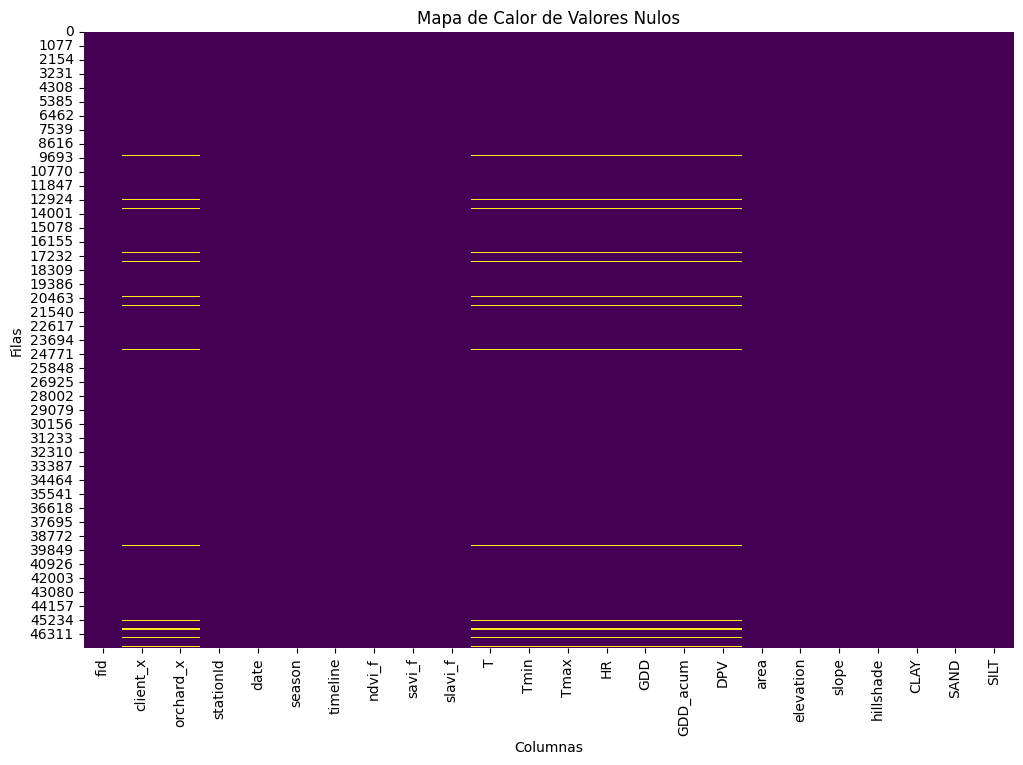

In [256]:
# Crear el mapa de calor de valores nulos
plt.figure(figsize=(12, 8))
sns.heatmap(df_full.isna(), cbar=False, cmap='viridis')

# Título y ejes
plt.title('Mapa de Calor de Valores Nulos')
plt.xlabel('Columnas')
plt.ylabel('Filas')

# Mostrar el gráfico
plt.show()

*3.1.2 Correlaciones*

In [ ]:
plot_correlacion(df_full, 'df_full')


# 6.Análisis PCA

In [163]:
# Seleccion de posibles variables para modelacion
df_modelacion = df_full[['fid','season','timeline','area','ndvi_f','savi_f','slavi_f','GDD', 'GDD_acum', 'DPV','elevation', 'slope','hillshade','CLAY','SILT','SAND']]

In [166]:
# Eliminación de datos NA
df_modelacion = df_modelacion.dropna()
print(df_modelacion.describe())

           timeline          area        ndvi_f        savi_f       slavi_f  \
count  46244.000000  46244.000000  46244.000000  46244.000000  46244.000000   
mean     113.973791      5.197410      0.541102      0.318635      1.235563   
std       66.809020      4.559974      0.109883      0.073824      0.377742   
min        0.000000      0.723744      0.140954      0.060036      0.437499   
25%       55.000000      2.066231      0.475125      0.274482      0.975719   
50%      115.000000      3.863663      0.554475      0.323501      1.191019   
75%      172.000000      6.372700      0.620215      0.369639      1.455866   
max      235.000000     24.323390      0.814603      0.526064      2.870976   

               GDD      GDD_acum           DPV     elevation         slope  \
count  46244.00000  46244.000000  46244.000000  46244.000000  46244.000000   
mean       8.22229    850.431891      0.763957    327.526248      1.951171   
std        3.71307    626.364498      0.357010    163.

In [168]:
# Seleccionar solo datos float y dejar fuera ndvi_f por ser variable a modelar
df_num = df_modelacion.select_dtypes(include=[float, int]).drop(columns=['ndvi_f'])

# Estandarización de los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

In [169]:
# Aplicación de PCA
pca = PCA(n_components=len(df_num.columns))
pca.fit(df_scaled)

PCA(n_components=13)

In [170]:
pca_t = pca.transform(df_scaled)
print(pca_t.shape)

(46244, 13)


In [174]:
#calcular la proporcion de la varianza explicada por cada PCA
print('varianza explicada PCA', pca_t.shape)
expl = pca.explained_variance_ratio_
print(expl)
print('suma',sum(expl[0:6]))

varianza explicada PCA (46244, 13)
[3.21916014e-01 2.44175956e-01 1.11078274e-01 8.69369462e-02
 8.25947413e-02 6.47847220e-02 5.53654111e-02 1.42888757e-02
 8.11732887e-03 5.46917920e-03 3.92335037e-03 1.34870854e-03
 4.92329037e-07]
suma 0.9114866538929365


Text(0, 0.5, 'Varianza explicada acumulada')

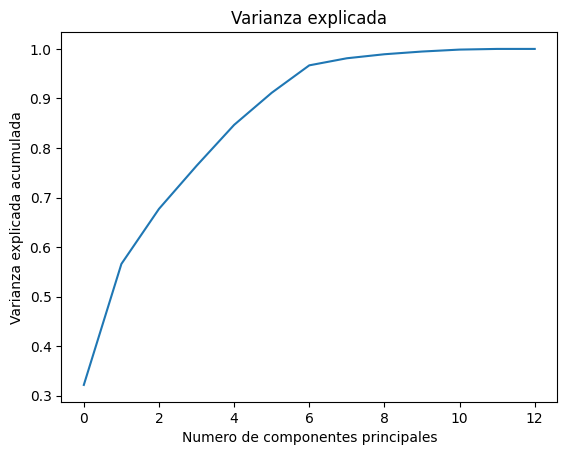

In [173]:
#graficar la avarianza acumulada
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('Varianza explicada')
plt.xlabel('Numero de componentes principales')
plt.ylabel('Varianza explicada acumulada')

In [175]:
# Cargas de las variables en cada componente principal
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(df_num.columns))], index=df_num.columns)

print("\nCargas de las variables en los componentes principales:")
print(loadings)


Cargas de las variables en los componentes principales:
                PC1       PC2       PC3       PC4       PC5       PC6  \
timeline   0.037835 -0.415464  0.530911 -0.149302  0.032171  0.002653   
area      -0.171390  0.017930  0.152936  0.233672 -0.542708 -0.543931   
savi_f    -0.050759 -0.400635 -0.455405 -0.154856  0.079384  0.039085   
slavi_f   -0.081329 -0.421288 -0.261928 -0.378124  0.135409  0.011100   
GDD        0.071985 -0.434973 -0.159042  0.433028 -0.122057 -0.024227   
GDD_acum   0.068913 -0.392406  0.562606 -0.143424  0.013673  0.009465   
DPV        0.155823 -0.369217 -0.189431  0.474673 -0.116396 -0.044924   
elevation  0.469316  0.031380 -0.009923  0.002640 -0.015428  0.014679   
slope     -0.154167  0.030930  0.194535  0.514743  0.232715  0.602464   
hillshade  0.023267 -0.017711 -0.055586 -0.240229 -0.772384  0.580024   
CLAY      -0.474314 -0.051909 -0.002183  0.008305 -0.013323  0.011596   
SILT       0.480347  0.049111 -0.000556 -0.001881  0.003667 -0.0061